# Mind2Web Evaluation Notebook

Evaluate fine-tuned checkpoints on Mind2Web dataset and select the best one.

This notebook provides an interactive way to:
- Evaluate a single checkpoint
- Evaluate all checkpoints in a directory
- Compare and rank checkpoints by accuracy

## 1. Setup and Imports

In [1]:
# Install required dependencies (run this on Colab or if packages are missing)
# ⚠️ Magma requires transformers 4.49.0 - 4.51.x (NOT 5.x which has breaking changes)

%pip install open_clip_torch peft bitsandbytes accelerate -q
%pip install "transformers>=4.49.0,<5.0.0" -q  # Pin to 4.x to avoid breaking changes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 48.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 37.0 MB/s eta 0:00:0000:0100:01


In [2]:
# ⚠️ IMPORTANT: After installing transformers, you may need to restart the kernel!
# In Colab: Runtime -> Restart runtime
# Then re-run all cells from the beginning

import transformers
print(f"Transformers version: {transformers.__version__}")

# Check version requirement
from packaging import version
tf_version = version.parse(transformers.__version__)

if tf_version < version.parse("4.49.0"):
    print("⚠️ Transformers version is too old! Magma requires >=4.49.0")
    print("⚠️ Please restart the kernel for the new transformers version to take effect!")
elif tf_version >= version.parse("5.0.0"):
    print("⚠️ Transformers 5.x detected - this has breaking changes with Magma!")
    print("⚠️ Please run: %pip install 'transformers>=4.49.0,<5.0.0' -q")
    print("⚠️ Then restart the kernel!")
else:
    print("✅ Transformers version is compatible with Magma")

Transformers version: 4.57.6
✅ Transformers version is compatible with Magma


### ⚠️ Kernel Restart Required

After running the installation cell above, you **MUST restart the kernel** for the new transformers version to take effect.

**Important:** Magma requires `transformers>=4.49.0,<5.0.0`. Version 5.x has breaking changes that are incompatible with the Magma model code on HuggingFace Hub.

**In Google Colab:** Runtime → Restart runtime

**In VS Code/Jupyter:** Kernel → Restart Kernel

Then run all cells from the beginning again.

In [3]:
import os
import sys
import json
import glob
import torch
from tqdm.notebook import tqdm
from PIL import Image
from peft import PeftModel
from transformers import BitsAndBytesConfig, AutoModelForCausalLM, AutoProcessor

# Detect environment and set project root accordingly
def get_project_root():
    """Find the project root directory."""
    cwd = os.getcwd()
    
    # Check if running on Google Colab
    if cwd == '/content':
        # Clone repo if not already present
        repo_path = '/content/Magma'
        if not os.path.exists(repo_path):
            print("Running on Colab - cloning repository...")
            os.system('git clone https://github.com/microsoft/Magma.git /content/Magma')
        return repo_path
    
    # Local environment - search for project root
    # Try current directory first
    if os.path.exists(os.path.join(cwd, 'magma', 'modeling_magma.py')):
        return cwd
    
    # Search upward from current directory
    current = cwd
    for _ in range(5):  # Search up to 5 levels
        if os.path.exists(os.path.join(current, 'magma', 'modeling_magma.py')):
            return current
        parent = os.path.dirname(current)
        if parent == current:  # Reached root
            break
        current = parent
    
    # Fallback: Windows default path
    win_path = r"c:\Users\Asus\OneDrive\Documents\my_cv\Magma"
    if os.path.exists(win_path):
        return win_path
    
    raise RuntimeError("Could not find Magma project root. Please set project_root manually.")

project_root = get_project_root()

print(f"Project root: {project_root}")
print(f"Current working directory: {os.getcwd()}")

print(f"✅ Imports ready!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

Running on Colab - cloning repository...
Project root: /content/Magma
Current working directory: /content
✅ Imports ready!
PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA device: NVIDIA A100-SXM4-40GB


In [4]:
# Patch for PyTorch 2.10+ compatibility with Magma model
# The model uses sum() on boolean tensors which requires explicit conversion in newer PyTorch

import torch

# Store original sum function (only if not already patched)
if not hasattr(torch, '_original_sum_backup'):
    torch._original_sum_backup = torch.sum

def _patched_sum(input, *args, **kwargs):
    """Patched sum that converts bool tensors to long before summing with dim."""
    # Handle plain Python bool - convert to tensor first
    if isinstance(input, bool):
        input = torch.tensor(input, dtype=torch.long)
    # Handle boolean tensors
    elif isinstance(input, torch.Tensor) and input.dtype == torch.bool and (len(args) > 0 or 'dim' in kwargs):
        input = input.long()
    return torch._original_sum_backup(input, *args, **kwargs)

# Apply patch
torch.sum = _patched_sum
print("✅ Applied PyTorch sum() patch for boolean tensor compatibility")

✅ Applied PyTorch sum() patch for boolean tensor compatibility


## 2. Configuration

Set your evaluation parameters here:

In [5]:
# ============ CONFIGURATION ============

# Base model name (from HuggingFace)
BASE_MODEL = "microsoft/Magma-8B"

# LoRA adapter checkpoint - can be HuggingFace hub ID or local path
# Set to None to use base model without LoRA adapters
CHECKPOINT_PATH = None  # Using base model only for now

# Path to directory containing multiple checkpoints (for comparing checkpoints)
CHECKPOINT_DIR = None

# Evaluate all checkpoints in directory
EVAL_ALL = False

# Load Mind2Web dataset from HuggingFace
LOAD_FROM_HF = True  # Set to False to load from local path
HF_DATASET_NAME = "MagmaAI/Magma-Mind2Web-SoM"  # Dataset with SoM screenshots!
HF_DATASET_SPLIT = "train"  # Check available splits after loading

# Local dataset path (used if LOAD_FROM_HF is False)
LOCAL_DATA_PATH = os.path.join(project_root, "datasets/mind2web")

# Output directory for results
OUTPUT_DIR = os.path.join(project_root, "results/mind2web_eval")

# Maximum samples to evaluate - just 2 examples for testing
MAX_SAMPLES = 2

# Use 4-bit quantization - disabled for now
USE_4BIT = False

# ========================================

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

# Print configuration
print(f"\n📋 Configuration:")
print(f"   Base model: {BASE_MODEL}")
print(f"   Checkpoint: {CHECKPOINT_PATH if CHECKPOINT_PATH else 'None (using base model)'}")
print(f"   Load from HuggingFace: {LOAD_FROM_HF}")
if LOAD_FROM_HF:
    print(f"   HF Dataset: {HF_DATASET_NAME} (split: {HF_DATASET_SPLIT})")
else:
    print(f"   Local data path: {LOCAL_DATA_PATH}")
print(f"   Max samples: {MAX_SAMPLES}")
print(f"   Use 4-bit quantization: {USE_4BIT}")

Output directory: /content/Magma/results/mind2web_eval

📋 Configuration:
   Base model: microsoft/Magma-8B
   Checkpoint: None (using base model)
   Load from HuggingFace: True
   HF Dataset: MagmaAI/Magma-Mind2Web-SoM (split: train)
   Max samples: 2
   Use 4-bit quantization: False


## 3. Helper Functions

In [6]:
# Helper Functions - Exact same loading approach as run_som_colab.ipynb
from transformers import AutoModelForCausalLM, AutoProcessor

# Global model dtype (same as run_som_colab)
MODEL_DTYPE = torch.bfloat16
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def load_model(checkpoint_path: str = None, base_model: str = "microsoft/Magma-8B", use_4bit: bool = False):
    """Load model using EXACTLY the same approach as run_som_colab.ipynb."""
    print(f"Loading base model: {base_model}")
    print(f"Device: {DEVICE}, dtype: {MODEL_DTYPE}")

    # Exact same loading as run_som_colab.ipynb Cell 9
    try:
        model = AutoModelForCausalLM.from_pretrained(
            base_model,
            trust_remote_code=True,
            torch_dtype=MODEL_DTYPE,
            device_map="auto",
            attn_implementation="eager"  # Same as run_som_colab
        )
        processor = AutoProcessor.from_pretrained(
            base_model,
            trust_remote_code=True
        )
        print("✓ Model loaded successfully!")
    except Exception as e:
        print(f"⚠ Error loading model: {e}")
        print("\nTrying alternative loading method...")
        model = AutoModelForCausalLM.from_pretrained(
            base_model,
            trust_remote_code=True,
            torch_dtype=MODEL_DTYPE,
            device_map="auto",
            attn_implementation="eager",
            use_flash_attention_2=False
        )
        processor = AutoProcessor.from_pretrained(
            base_model,
            trust_remote_code=True
        )
        print("✓ Model loaded (without flash attention)")

    # Load LoRA adapters if provided
    if checkpoint_path and os.path.exists(checkpoint_path):
        print(f"Loading LoRA adapters from: {checkpoint_path}")
        model = PeftModel.from_pretrained(model, checkpoint_path)
        print("LoRA adapters loaded!")

    model.eval()
    print("✅ Model ready for inference!")
    return model, processor

In [7]:
def run_inference(model, processor, image: Image.Image, prompt: str) -> str:
    """Run inference on a single sample for Mind2Web evaluation.
    
    Note: The prompt should already have <image> removed - we add it back here with proper format.
    """
    
    # Handle image token format based on model config
    if hasattr(model.config, 'mm_use_image_start_end') and model.config.mm_use_image_start_end:
        image_token = "<image_start><image><image_end>"
    else:
        image_token = "<image>"
    
    # Build conversation - use the SAME format as training data
    # The prompt from Mind2Web dataset already contains all instructions
    convs = [
        {"role": "system", "content": "You are agent that can see, talk and act."},
        {"role": "user", "content": f"{image_token}\n{prompt}"},
    ]

    formatted_prompt = processor.tokenizer.apply_chat_template(
        convs, tokenize=False, add_generation_prompt=True
    )
    
    # Process inputs
    inputs = processor(images=[image], texts=formatted_prompt, return_tensors="pt")
    inputs['pixel_values'] = inputs['pixel_values'].unsqueeze(0)
    inputs['image_sizes'] = inputs['image_sizes'].unsqueeze(0)
    
    # Move to device and convert dtypes
    inputs = inputs.to(MODEL_DTYPE).to(DEVICE)

    # Set pad_token_id to avoid warning
    model.generation_config.pad_token_id = processor.tokenizer.pad_token_id

    # Generate response - increase max_new_tokens for longer JSON output
    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            temperature=0.0,
            do_sample=False,
            num_beams=1,
            max_new_tokens=256,  # Increased for JSON output
            use_cache=False  # Avoid DynamicCache compatibility issue
        )

    # Decode response
    prompt_decoded = processor.batch_decode(inputs['input_ids'], skip_special_tokens=True)[0]
    response = processor.batch_decode(output_ids, skip_special_tokens=True)[0]
    response = response.replace(prompt_decoded, '').strip()

    return response

In [8]:
import re

def parse_action(response: str) -> dict:
    """Parse model response to extract action dict."""
    try:
        return json.loads(response)
    except json.JSONDecodeError:
        json_match = re.search(r'\{.*\}', response, re.DOTALL)
        if json_match:
            try:
                return json.loads(json_match.group())
            except:
                pass
        return {"raw_response": response, "parse_error": True}

In [9]:
def compute_metrics(results: list) -> dict:
    """Compute evaluation metrics."""
    total = len(results)
    action_correct = 0
    element_correct = 0
    value_correct = 0
    overall_correct = 0
    parse_errors = 0

    for r in results:
        gt = r['ground_truth']
        pred = r['prediction']

        if pred.get('parse_error'):
            parse_errors += 1
            continue

        # Action accuracy
        action_match = pred.get('ACTION') == gt.get('ACTION')
        if action_match:
            action_correct += 1

        # Element accuracy (MARK)
        element_match = str(pred.get('MARK')) == str(gt.get('MARK'))
        if element_match:
            element_correct += 1

        # Value accuracy (for TYPE actions)
        value_match = True
        if gt.get('ACTION') == 'TYPE':
            value_match = pred.get('VALUE') == gt.get('VALUE')
            if value_match:
                value_correct += 1

        # Overall accuracy
        if action_match and element_match and (gt.get('ACTION') != 'TYPE' or value_match):
            overall_correct += 1

    valid = total - parse_errors

    metrics = {
        'total_samples': total,
        'valid_samples': valid,
        'parse_errors': parse_errors,
        'action_accuracy': action_correct / valid if valid > 0 else 0,
        'element_accuracy': element_correct / valid if valid > 0 else 0,
        'value_accuracy': value_correct / valid if valid > 0 else 0,
        'overall_accuracy': overall_correct / valid if valid > 0 else 0,
    }

    return metrics

In [10]:
def evaluate_checkpoint(checkpoint_path: str, dataset, base_model: str,
                        max_samples: int = None, use_4bit: bool = False, 
                        data_dir: str = None, is_hf_dataset: bool = False) -> dict:
    """Evaluate a single checkpoint."""
    print(f"\n{'='*60}")
    print(f"Evaluating: {checkpoint_path if checkpoint_path else 'Base model (no LoRA)'}")
    print('='*60)

    # Load model with checkpoint (same approach as run_som_colab)
    model, processor = load_model(checkpoint_path, base_model, use_4bit)

    # Prepare samples
    if max_samples:
        if is_hf_dataset:
            samples = dataset.select(range(min(max_samples, len(dataset))))
        else:
            samples = dataset[:min(max_samples, len(dataset))]
    else:
        samples = dataset

    # Run inference
    results = []
    
    for idx, sample in enumerate(tqdm(samples, desc="Evaluating")):
        try:
            if is_hf_dataset:
                # MagmaAI/Magma-Mind2Web-SoM format
                # Has: id, image (PIL), conversations
                image = sample['image']
                if hasattr(image, 'convert'):
                    image = image.convert('RGB')
                
                # Get conversations
                convs = sample.get('conversations', [])
                if len(convs) >= 2:
                    # User prompt (remove <image> tag for processing)
                    user_prompt = convs[0].get('value', convs[0].get('content', ''))
                    user_prompt = user_prompt.replace('<image>', '').strip()
                    
                    # Ground truth from assistant response
                    gt_value = convs[1].get('value', convs[1].get('content', ''))
                    if isinstance(gt_value, str):
                        try:
                            ground_truth = json.loads(gt_value)
                        except json.JSONDecodeError:
                            ground_truth = {"raw": gt_value}
                    else:
                        ground_truth = gt_value
                else:
                    print(f"Warning: Invalid conversation format in sample {idx}")
                    continue
                
                sample_id = sample.get('id', idx)
                
            else:
                # Local JSON format
                image_path = os.path.join(data_dir, sample['image'])
                image = Image.open(image_path).convert('RGB')
                
                user_prompt = sample['conversations'][0]['value'].replace("<image>", "").strip()
                gt_value = sample['conversations'][1]['value']
                
                if isinstance(gt_value, str):
                    try:
                        ground_truth = json.loads(gt_value)
                    except json.JSONDecodeError:
                        ground_truth = {"raw": gt_value}
                else:
                    ground_truth = gt_value
                
                sample_id = sample['id']

            response = run_inference(model, processor, image, user_prompt)
            prediction = parse_action(response)

            results.append({
                "id": sample_id,
                "ground_truth": ground_truth,
                "prediction": prediction,
                "raw_response": response
            })
        except Exception as e:
            print(f"Error processing sample {idx}: {e}")
            import traceback
            traceback.print_exc()
            continue

    # Compute metrics
    metrics = compute_metrics(results)
    metrics['checkpoint'] = checkpoint_path if checkpoint_path else "base_model"

    # Print results
    print(f"\n📊 Results for {os.path.basename(checkpoint_path) if checkpoint_path else 'Base Model'}:")
    print(f"   Action Accuracy:  {metrics['action_accuracy']*100:.2f}%")
    print(f"   Element Accuracy: {metrics['element_accuracy']*100:.2f}%")
    print(f"   Value Accuracy:   {metrics['value_accuracy']*100:.2f}%")
    print(f"   Overall Accuracy: {metrics['overall_accuracy']*100:.2f}%")
    print(f"   Parse Errors:     {metrics['parse_errors']}/{metrics['total_samples']}")

    # Clean up
    del model
    torch.cuda.empty_cache()

    return metrics, results

## 4. Load Dataset

In [11]:
# Load Mind2Web dataset
from datasets import load_dataset
from io import BytesIO
import base64

if LOAD_FROM_HF:
    print(f"Loading Mind2Web dataset from HuggingFace: {HF_DATASET_NAME}")
    print(f"Split: {HF_DATASET_SPLIT}")
    
    # Load dataset from HuggingFace
    hf_dataset = load_dataset(HF_DATASET_NAME, split=HF_DATASET_SPLIT)
    print(f"Dataset loaded! Size: {len(hf_dataset)}")
    
    # Print column names to understand the structure
    print(f"Columns: {hf_dataset.column_names}")
    
    # Convert to list format compatible with our evaluation
    dataset = hf_dataset
    data_dir = None  # Images are embedded in the dataset
    
else:
    # Load from local JSON file
    print(f"Loading dataset from local path: {LOCAL_DATA_PATH}")
    
    if LOCAL_DATA_PATH.endswith('.json'):
        json_path = LOCAL_DATA_PATH
        data_dir = os.path.dirname(LOCAL_DATA_PATH)
    else:
        data_dir = LOCAL_DATA_PATH
        val_json = os.path.join(LOCAL_DATA_PATH, "mind2web_val.json")
        test_json = os.path.join(LOCAL_DATA_PATH, "mind2web_test.json")
        train_json = os.path.join(LOCAL_DATA_PATH, "mind2web_train.json")

        if os.path.exists(val_json):
            json_path = val_json
        elif os.path.exists(test_json):
            json_path = test_json
        elif os.path.exists(train_json):
            print("Warning: Using train.json for evaluation (no val/test found)")
            json_path = train_json
        else:
            raise FileNotFoundError(f"No JSON files found in {LOCAL_DATA_PATH}")

    print(f"Loading from: {json_path}")
    with open(json_path, 'r') as f:
        dataset = json.load(f)

    print(f"Dataset size: {len(dataset)}")
    print(f"Data directory: {data_dir}")

Loading Mind2Web dataset from HuggingFace: MagmaAI/Magma-Mind2Web-SoM
Split: train


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data-00000-of-00012.arrow:   0%|          | 0.00/476M [00:00<?, ?B/s]

data-00001-of-00012.arrow:   0%|          | 0.00/453M [00:00<?, ?B/s]

...

data-00009-of-00012.arrow:   0%|          | 0.00/487M [00:00<?, ?B/s]

data-00010-of-00012.arrow:   0%|          | 0.00/461M [00:00<?, ?B/s]

data-00011-of-00012.arrow:   0%|          | 0.00/435M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset loaded! Size: 7357
Columns: ['id', 'image', 'conversations']


### Preview Dataset Sample

📋 Dataset Structure:
Columns: ['id', 'image', 'conversations']

🆔 Sample ID: mind2web_3362

🖼️  Image type: <class 'PIL.PngImagePlugin.PngImageFile'>
   Image size: (1292, 1536)
   Image mode: RGB

💬 Conversations (2 turns):
   [0] user: <image>
Imagine that you are imitating humans doing web navigation for a task step by step. At each stage, you can see the webpage like humans by a screenshot and know the previous actions before the current step decided by yourself through recorded history. You need to decide on the following actio...
   [1] assistant: {"ACTION": "TYPE", "MARK": 11, "VALUE": "Jeerimiah Waton"}

🖼️  First sample image:


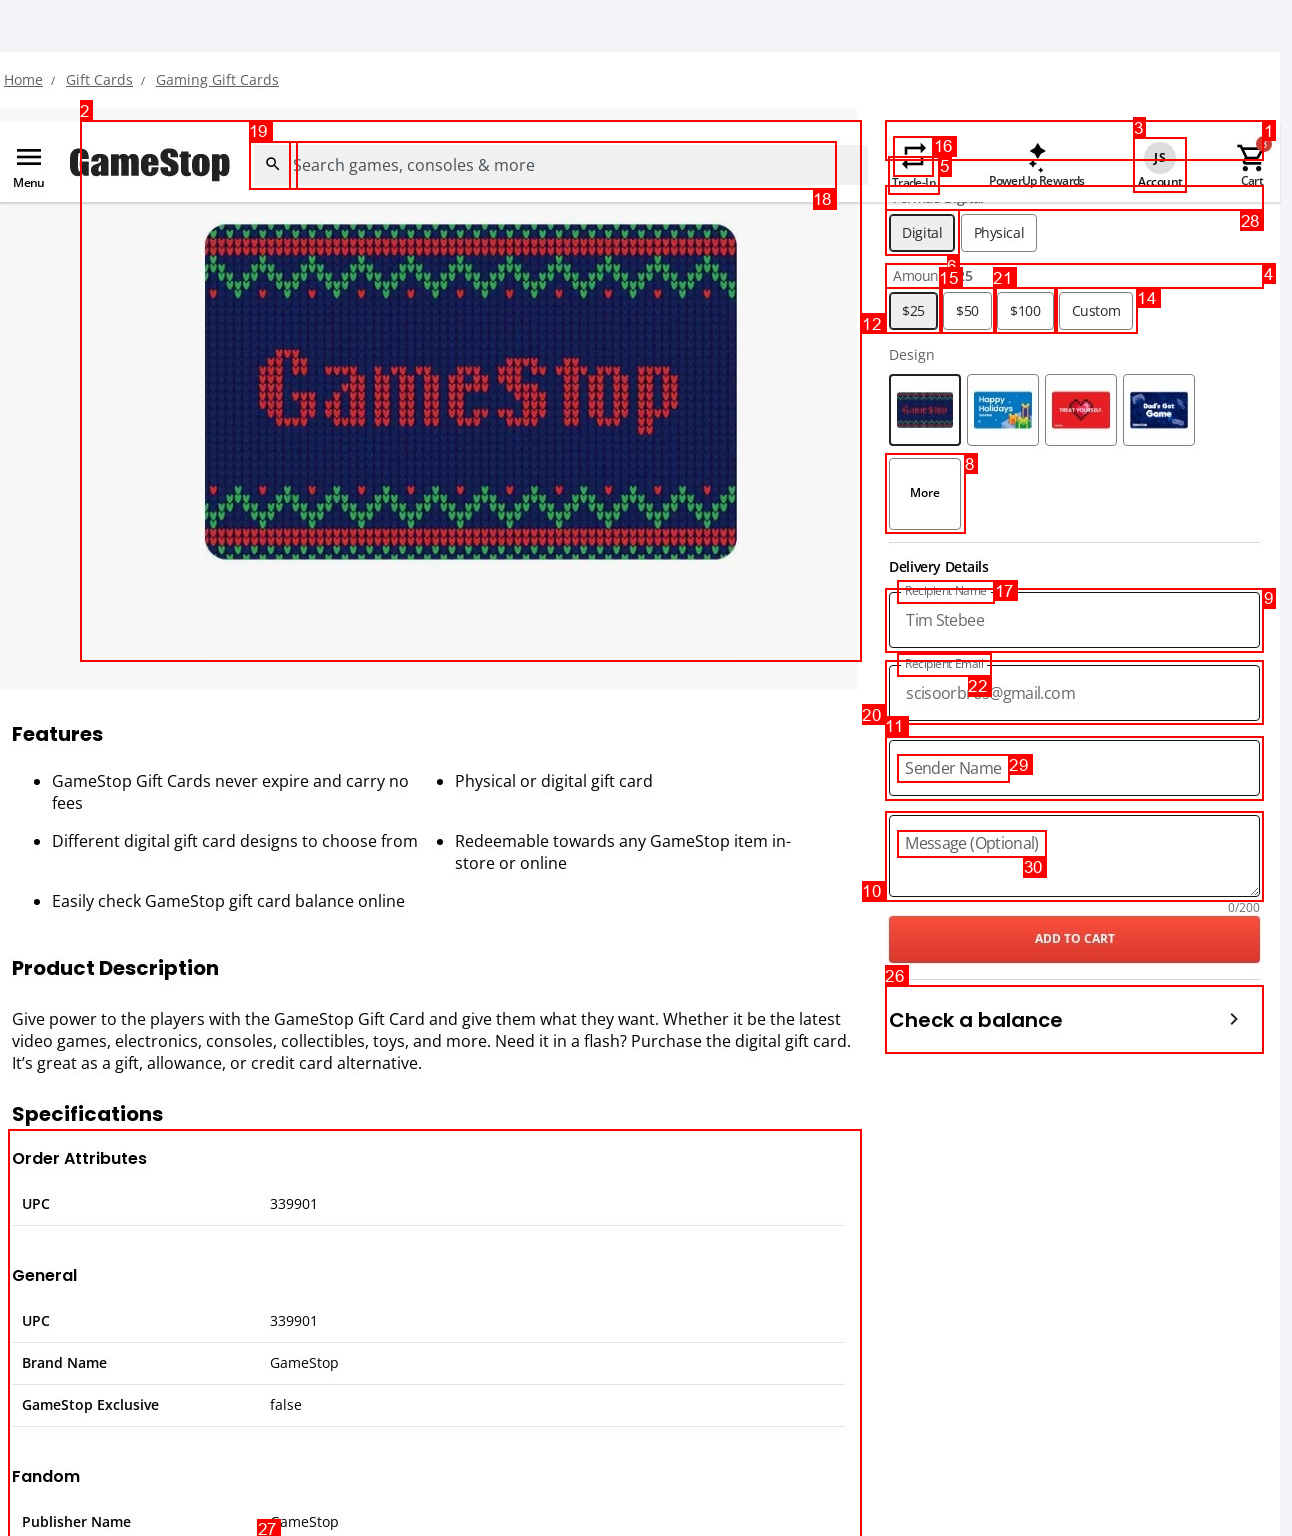

In [12]:
# Preview dataset structure
if len(dataset) > 0:
    sample = dataset[0]
    print("📋 Dataset Structure:")
    print("="*60)
    print(f"Columns: {list(sample.keys())}")
    
    print(f"\n🆔 Sample ID: {sample.get('id', 'N/A')}")
    
    # Check image
    if 'image' in sample:
        img = sample['image']
        print(f"\n🖼️  Image type: {type(img)}")
        if hasattr(img, 'size'):
            print(f"   Image size: {img.size}")
        if hasattr(img, 'mode'):
            print(f"   Image mode: {img.mode}")
    
    # Check conversations
    if 'conversations' in sample:
        print(f"\n💬 Conversations ({len(sample['conversations'])} turns):")
        for i, conv in enumerate(sample['conversations']):
            role = conv.get('from', conv.get('role', 'unknown'))
            value = conv.get('value', conv.get('content', ''))
            # Truncate long values
            value_display = value[:300] + "..." if len(str(value)) > 300 else value
            print(f"   [{i}] {role}: {value_display}")
    
    # Display the image
    print("\n🖼️  First sample image:")
    if 'image' in sample and sample['image'] is not None:
        display(sample['image'])

## 5. Run Evaluation

In [13]:
all_metrics = []

# Determine if using HuggingFace dataset
is_hf_dataset = LOAD_FROM_HF

if EVAL_ALL and CHECKPOINT_DIR:
    # Find all checkpoints
    checkpoints = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, "checkpoint-*")))
    print(f"Found {len(checkpoints)} checkpoints")

    for ckpt in checkpoints:
        metrics, results = evaluate_checkpoint(
            ckpt, dataset, BASE_MODEL, MAX_SAMPLES, USE_4BIT, 
            data_dir if not is_hf_dataset else None, is_hf_dataset
        )
        all_metrics.append(metrics)

        # Save individual results
        ckpt_name = os.path.basename(ckpt)
        with open(os.path.join(OUTPUT_DIR, f"{ckpt_name}_results.json"), 'w') as f:
            json.dump({"metrics": metrics, "predictions": results}, f, indent=2)

elif CHECKPOINT_PATH or not EVAL_ALL:
    # Evaluate single checkpoint or base model
    metrics, results = evaluate_checkpoint(
        CHECKPOINT_PATH, dataset, BASE_MODEL, MAX_SAMPLES, USE_4BIT,
        data_dir if not is_hf_dataset else None, is_hf_dataset
    )
    all_metrics.append(metrics)

    ckpt_name = os.path.basename(CHECKPOINT_PATH) if CHECKPOINT_PATH else "base_model"
    with open(os.path.join(OUTPUT_DIR, f"{ckpt_name}_results.json"), 'w') as f:
        json.dump({"metrics": metrics, "predictions": results}, f, indent=2)
    print(f"\nResults saved to: {OUTPUT_DIR}/{ckpt_name}_results.json")

else:
    print("Please set CHECKPOINT_PATH or set CHECKPOINT_DIR with EVAL_ALL=True")


Evaluating: Base model (no LoRA)
Loading base model: microsoft/Magma-8B
Device: cuda, dtype: torch.bfloat16


config.json: 0.00B [00:00, ?B/s]

configuration_magma.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Magma-8B:
- configuration_magma.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
`torch_dtype` is deprecated! Use `dtype` instead!


modeling_magma.py: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/434 [00:00<?, ?B/s]

✓ Model loaded successfully!
✅ Model ready for inference!


Evaluating:   0%|          | 0/2 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)



📊 Results for Base Model:
   Action Accuracy:  0.00%
   Element Accuracy: 0.00%
   Value Accuracy:   0.00%
   Overall Accuracy: 0.00%
   Parse Errors:     2/2

Results saved to: /content/Magma/results/mind2web_eval/base_model_results.json


Loading model for debug test...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Some weights of MagmaForCausalLM were not initialized from the model checkpoint at microsoft/Magma-8B and are newly initialized: ['vision_tower.clip_vision_model.head.proj.weight', 'vision_tower.clip_vision_model.trunk.head.norm.bias', 'vision_tower.clip_vision_model.trunk.head.norm.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Model config mm_use_image_start_end: True

INPUT IMAGE:


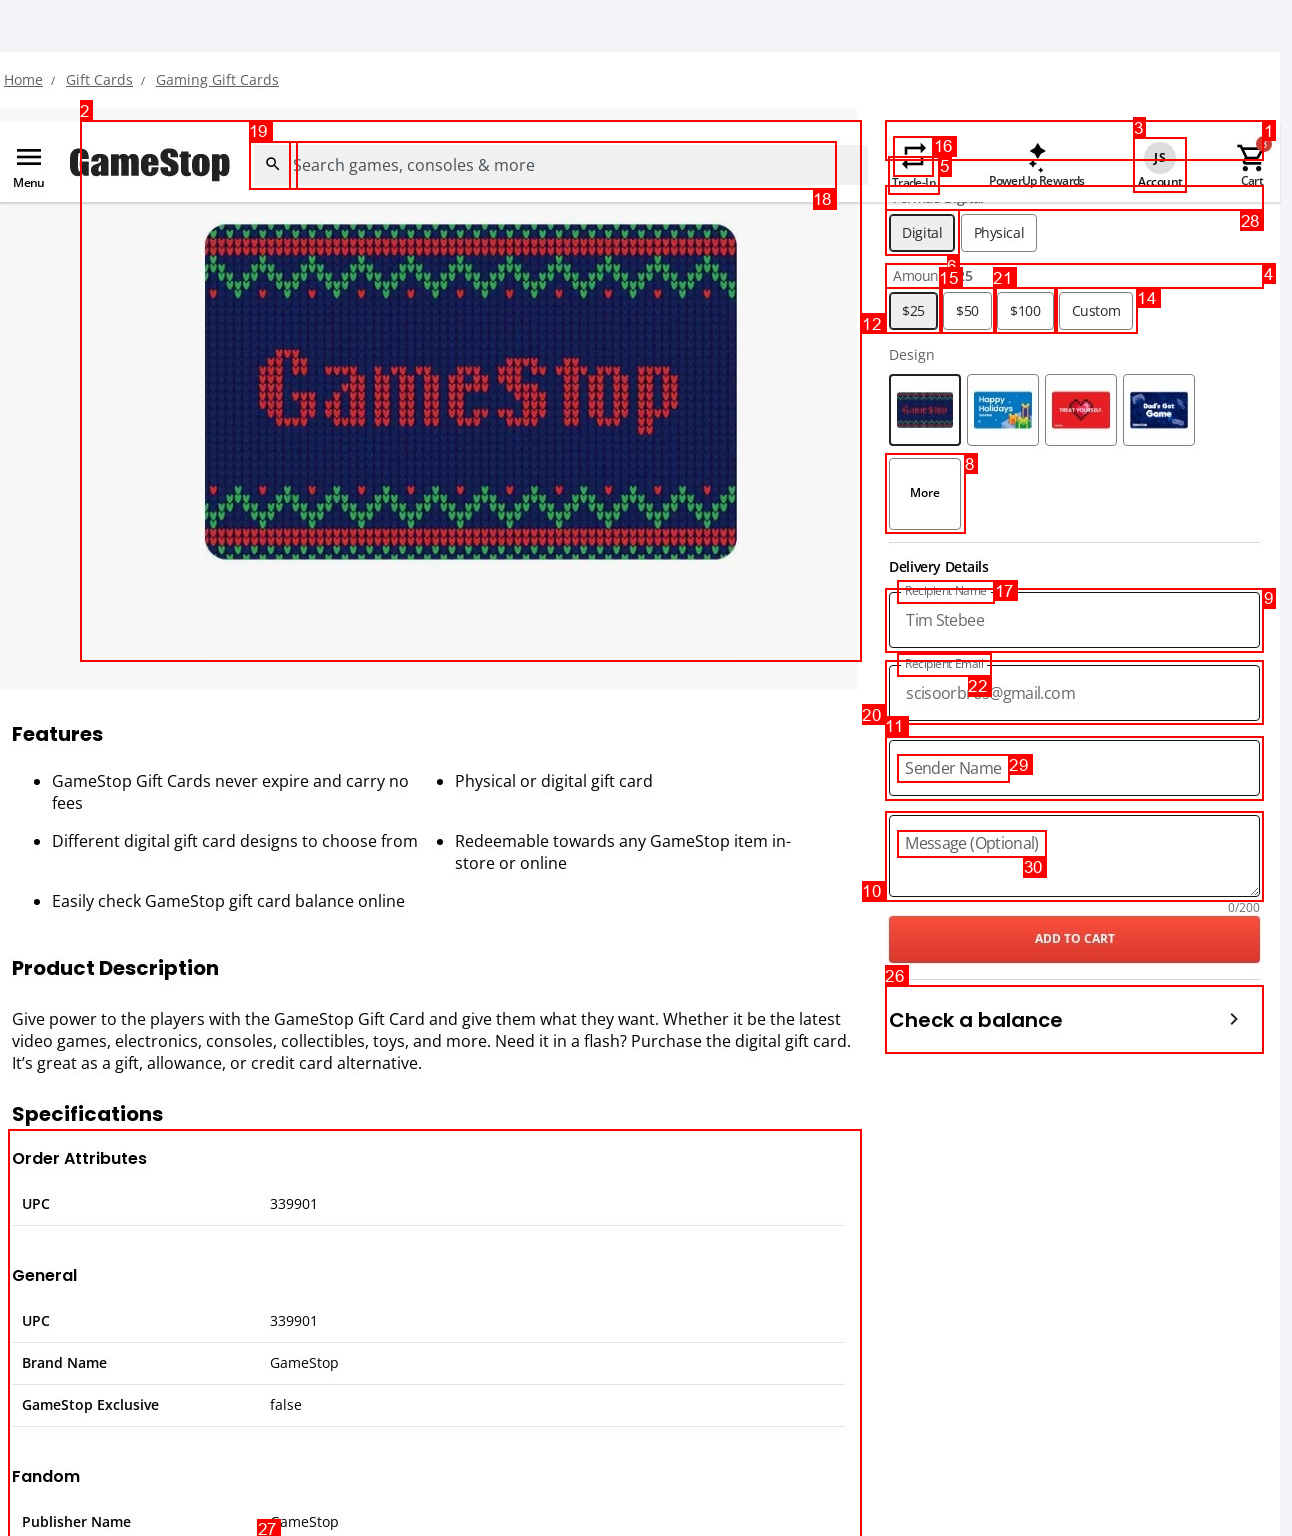


INPUT PROMPT (from dataset):
<image>
Imagine that you are imitating humans doing web navigation for a task step by step. At each stage, you can see the webpage like humans by a screenshot and know the previous actions before the current step decided by yourself through recorded history. You need to decide on the following action to take. You can click an element with the mouse, select an option, or type text with the keyboard. The output format should be a dictionary like: 
"{"ACTION": "CLICK" or "TYPE" or "SELECT", "MARK": a numeric id, e.g., 5, "VALUE": a string value for the action if applicable, otherwise None}".
You are asked to complete the following task: Buy a $25 digital gift card for Tim Stebee, whose email address is scisoorbros@gmail.com. Fill in sender name Jeerimiah Waton. The previous actions you have taken: 

[textbox]  Recipient Name -> TYPE: Tim Stebee
[textbox]  Recipient Email -> TYPE: scisoorbros@gmail.com
For your convinience, I have labeled the candidates with n

In [19]:
# DEBUG: Check model config and test inference directly
from transformers import AutoModelForCausalLM, AutoProcessor
from IPython.display import display
import torch
import json

# Load model fresh for testing
print("Loading model for debug test...")
test_model = AutoModelForCausalLM.from_pretrained(
    "microsoft/Magma-8B",
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="eager"
)
test_processor = AutoProcessor.from_pretrained("microsoft/Magma-8B", trust_remote_code=True)

print(f"\nModel config mm_use_image_start_end: {test_model.config.mm_use_image_start_end}")

# Get sample image and FULL prompt from dataset
sample = dataset[0]
image = sample['image'].convert('RGB')
full_prompt = sample['conversations'][0]['value']  # Keep <image> tag

# Display the image
print(f"\n{'='*60}")
print("INPUT IMAGE:")
print('='*60)
display(image)

print(f"\n{'='*60}")
print("INPUT PROMPT (from dataset):")
print('='*60)
print(full_prompt)

# Handle image token
if test_model.config.mm_use_image_start_end:
    full_prompt = full_prompt.replace('<image>', '<image_start><image><image_end>')

# Build conversation WITHOUT removing anything
convs = [
    {"role": "system", "content": "You are agent that can see, talk and act."},
    {"role": "user", "content": full_prompt},
]

formatted_prompt = test_processor.tokenizer.apply_chat_template(
    convs, tokenize=False, add_generation_prompt=True
)

# Run inference
inputs = test_processor(images=[image], texts=formatted_prompt, return_tensors="pt")
inputs['pixel_values'] = inputs['pixel_values'].unsqueeze(0)
inputs['image_sizes'] = inputs['image_sizes'].unsqueeze(0)
inputs = inputs.to(torch.bfloat16).to('cuda')

test_model.generation_config.pad_token_id = test_processor.tokenizer.pad_token_id

print("\nRunning inference...")
with torch.inference_mode():
    output_ids = test_model.generate(
        **inputs,
        temperature=0.0,
        do_sample=False,
        num_beams=1,
        max_new_tokens=256,
        use_cache=False
    )

prompt_decoded = test_processor.batch_decode(inputs['input_ids'], skip_special_tokens=True)[0]
response = test_processor.batch_decode(output_ids, skip_special_tokens=True)[0]
response = response.replace(prompt_decoded, '').strip()

print(f"\n{'='*60}")
print("MODEL RESPONSE:")
print('='*60)
print(response)

print(f"\n{'='*60}")
print("EXPECTED OUTPUT:")
print('='*60)
expected_raw = sample['conversations'][1]['value']
try:
    expected_parsed = json.loads(expected_raw) if isinstance(expected_raw, str) else expected_raw
    print(json.dumps(expected_parsed, indent=2))
except json.JSONDecodeError:
    print(expected_raw)

# Cleanup
del test_model
torch.cuda.empty_cache()

## 6. Results Summary

In [15]:
# Display results summary
if all_metrics:
    import pandas as pd
    
    # Create DataFrame for better visualization
    df = pd.DataFrame(all_metrics)
    df['checkpoint_name'] = df['checkpoint'].apply(os.path.basename)
    
    # Reorder columns
    display_cols = ['checkpoint_name', 'overall_accuracy', 'action_accuracy', 
                    'element_accuracy', 'value_accuracy', 'valid_samples', 'parse_errors']
    df_display = df[display_cols].copy()
    
    # Format percentages
    for col in ['overall_accuracy', 'action_accuracy', 'element_accuracy', 'value_accuracy']:
        df_display[col] = (df_display[col] * 100).round(2).astype(str) + '%'
    
    print("\n📊 Evaluation Results Summary:")
    print("="*80)
    display(df_display)


📊 Evaluation Results Summary:


,checkpoint_name,overall_accuracy,action_accuracy,element_accuracy,value_accuracy,valid_samples,parse_errors
0,base_model,0%,0%,0%,0%,0,2


In [ ]:
# Rank checkpoints by overall accuracy (if multiple checkpoints evaluated)
if len(all_metrics) > 1:
    print("\n" + "="*60)
    print("📈 CHECKPOINT RANKING (by Overall Accuracy)")
    print("="*60)

    ranked = sorted(all_metrics, key=lambda x: x['overall_accuracy'], reverse=True)

    for i, m in enumerate(ranked):
        ckpt_name = os.path.basename(m['checkpoint'])
        print(f"{i+1}. {ckpt_name}: {m['overall_accuracy']*100:.2f}%")

    best = ranked[0]
    print(f"\n🏆 BEST CHECKPOINT: {os.path.basename(best['checkpoint'])}")
    print(f"   Overall Accuracy: {best['overall_accuracy']*100:.2f}%")

    # Save ranking
    with open(os.path.join(OUTPUT_DIR, "checkpoint_ranking.json"), 'w') as f:
        json.dump(ranked, f, indent=2)
    print(f"\nRanking saved to: {OUTPUT_DIR}/checkpoint_ranking.json")

## 7. Visualize Results (Optional)

In [ ]:
# Visualize metrics (if matplotlib is available)
try:
    import matplotlib.pyplot as plt
    
    if len(all_metrics) > 1:
        fig, ax = plt.subplots(figsize=(12, 6))
        
        checkpoints = [os.path.basename(m['checkpoint']) for m in all_metrics]
        overall_acc = [m['overall_accuracy'] * 100 for m in all_metrics]
        action_acc = [m['action_accuracy'] * 100 for m in all_metrics]
        element_acc = [m['element_accuracy'] * 100 for m in all_metrics]
        
        x = range(len(checkpoints))
        width = 0.25
        
        ax.bar([i - width for i in x], overall_acc, width, label='Overall', color='#2ecc71')
        ax.bar(x, action_acc, width, label='Action', color='#3498db')
        ax.bar([i + width for i in x], element_acc, width, label='Element', color='#e74c3c')
        
        ax.set_ylabel('Accuracy (%)')
        ax.set_title('Checkpoint Performance Comparison')
        ax.set_xticks(x)
        ax.set_xticklabels(checkpoints, rotation=45, ha='right')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, 'checkpoint_comparison.png'), dpi=150)
        plt.show()
        print(f"Chart saved to: {OUTPUT_DIR}/checkpoint_comparison.png")
    elif len(all_metrics) == 1:
        # Single checkpoint bar chart
        m = all_metrics[0]
        metrics_names = ['Overall', 'Action', 'Element', 'Value']
        metrics_values = [m['overall_accuracy']*100, m['action_accuracy']*100, 
                         m['element_accuracy']*100, m['value_accuracy']*100]
        
        fig, ax = plt.subplots(figsize=(8, 5))
        bars = ax.bar(metrics_names, metrics_values, color=['#2ecc71', '#3498db', '#e74c3c', '#9b59b6'])
        ax.set_ylabel('Accuracy (%)')
        ax.set_title(f'Evaluation Results: {os.path.basename(m["checkpoint"])}')
        ax.set_ylim(0, 100)
        
        # Add value labels on bars
        for bar, val in zip(bars, metrics_values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                   f'{val:.1f}%', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, 'evaluation_results.png'), dpi=150)
        plt.show()
        print(f"Chart saved to: {OUTPUT_DIR}/evaluation_results.png")
        
except ImportError:
    print("matplotlib not available. Skipping visualization.")

## 8. Inspect Sample Predictions (Optional)

In [20]:
# Inspect some predictions
if 'results' in dir() and results:
    print("\n🔍 Sample Predictions:")
    print("="*80)
    
    # Show first 5 predictions
    for i, r in enumerate(results[:5]):
        print(f"\n--- Sample {i+1} (ID: {r['id']}) ---")
        print(f"Ground Truth: {r['ground_truth']}")
        print(f"Prediction:   {r['prediction']}")
        print(f"Raw Response: {r['raw_response'][:200]}..." if len(r['raw_response']) > 200 else f"Raw Response: {r['raw_response']}")
        
        # Check correctness
        gt, pred = r['ground_truth'], r['prediction']
        if not pred.get('parse_error'):
            action_ok = pred.get('ACTION') == gt.get('ACTION')
            element_ok = str(pred.get('MARK')) == str(gt.get('MARK'))
            print(f"✓ Action: {'✅' if action_ok else '❌'} | Element: {'✅' if element_ok else '❌'}")
        else:
            print("⚠️ Parse error")


🔍 Sample Predictions:

--- Sample 1 (ID: mind2web_3362) ---
Ground Truth: {'ACTION': 'TYPE', 'MARK': 11, 'VALUE': 'Jeerimiah Waton'}
Prediction:   {'raw_response': 'Coordinate: (0.71, 0.10). Mark: 16.\nCoordinate: (0.78, 0.40). Mark: 17.\nCoordinate: (0.85, 0.11). Mark: 18.\nCoordinate: (0.37, 0.10). Mark: 19.\nCoordinate: (0.78, 0.56). Mark: 20.\nCoordinate: (0.85, 0.19). Mark: 21.\nCoordinate: (0.85, 0.43). Mark: 22.\nCoordinate: (0.85, 0', 'parse_error': True}
Raw Response: Coordinate: (0.71, 0.10). Mark: 16.
Coordinate: (0.78, 0.40). Mark: 17.
Coordinate: (0.85, 0.11). Mark: 18.
Coordinate: (0.37, 0.10). Mark: 19.
Coordinate: (0.78, 0.56). Mark: 20.
Coordinate: (0.85, 0...
⚠️ Parse error

--- Sample 2 (ID: mind2web_3361) ---
Ground Truth: {'ACTION': 'TYPE', 'MARK': 28, 'VALUE': 'scisoorbros@gmail.com'}
Prediction:   {'raw_response': 'Coordinate: (0.71, 0.49). Mark: 28.\nCoordinate: (0.81, 0.49). Mark: 29.\nCoordinate: (0.71, 0.53). Mark: 30.\nCoordinate: (0.81, 0.53). Mark: 31.\nC

In [ ]:
# Filter and show failed predictions
if 'results' in dir() and results:
    failed = [r for r in results if r['prediction'].get('parse_error') or 
              r['prediction'].get('ACTION') != r['ground_truth'].get('ACTION') or
              str(r['prediction'].get('MARK')) != str(r['ground_truth'].get('MARK'))]
    
    print(f"\n❌ Failed Predictions: {len(failed)}/{len(results)}")
    print("="*80)
    
    # Show first 3 failed predictions
    for i, r in enumerate(failed[:3]):
        print(f"\n--- Failed Sample {i+1} (ID: {r['id']}) ---")
        print(f"Ground Truth: {r['ground_truth']}")
        print(f"Prediction:   {r['prediction']}")
        print(f"Raw Response: {r['raw_response'][:300]}..." if len(r['raw_response']) > 300 else f"Raw Response: {r['raw_response']}")

## 9. Custom Image Evaluation with SOM

Load your own image from Google Drive, run SOM detection (YOLO + OCR), and evaluate with Magma.

In [1]:
# Cell 9.1: Install SOM dependencies
# Run this cell first if you haven't already installed these packages

%pip install -q ultralytics easyocr opencv-python-headless gdown
print("✓ SOM dependencies installed")

✓ SOM dependencies installed


✓ Downloaded image from Google Drive
  Size: (1920, 1080)


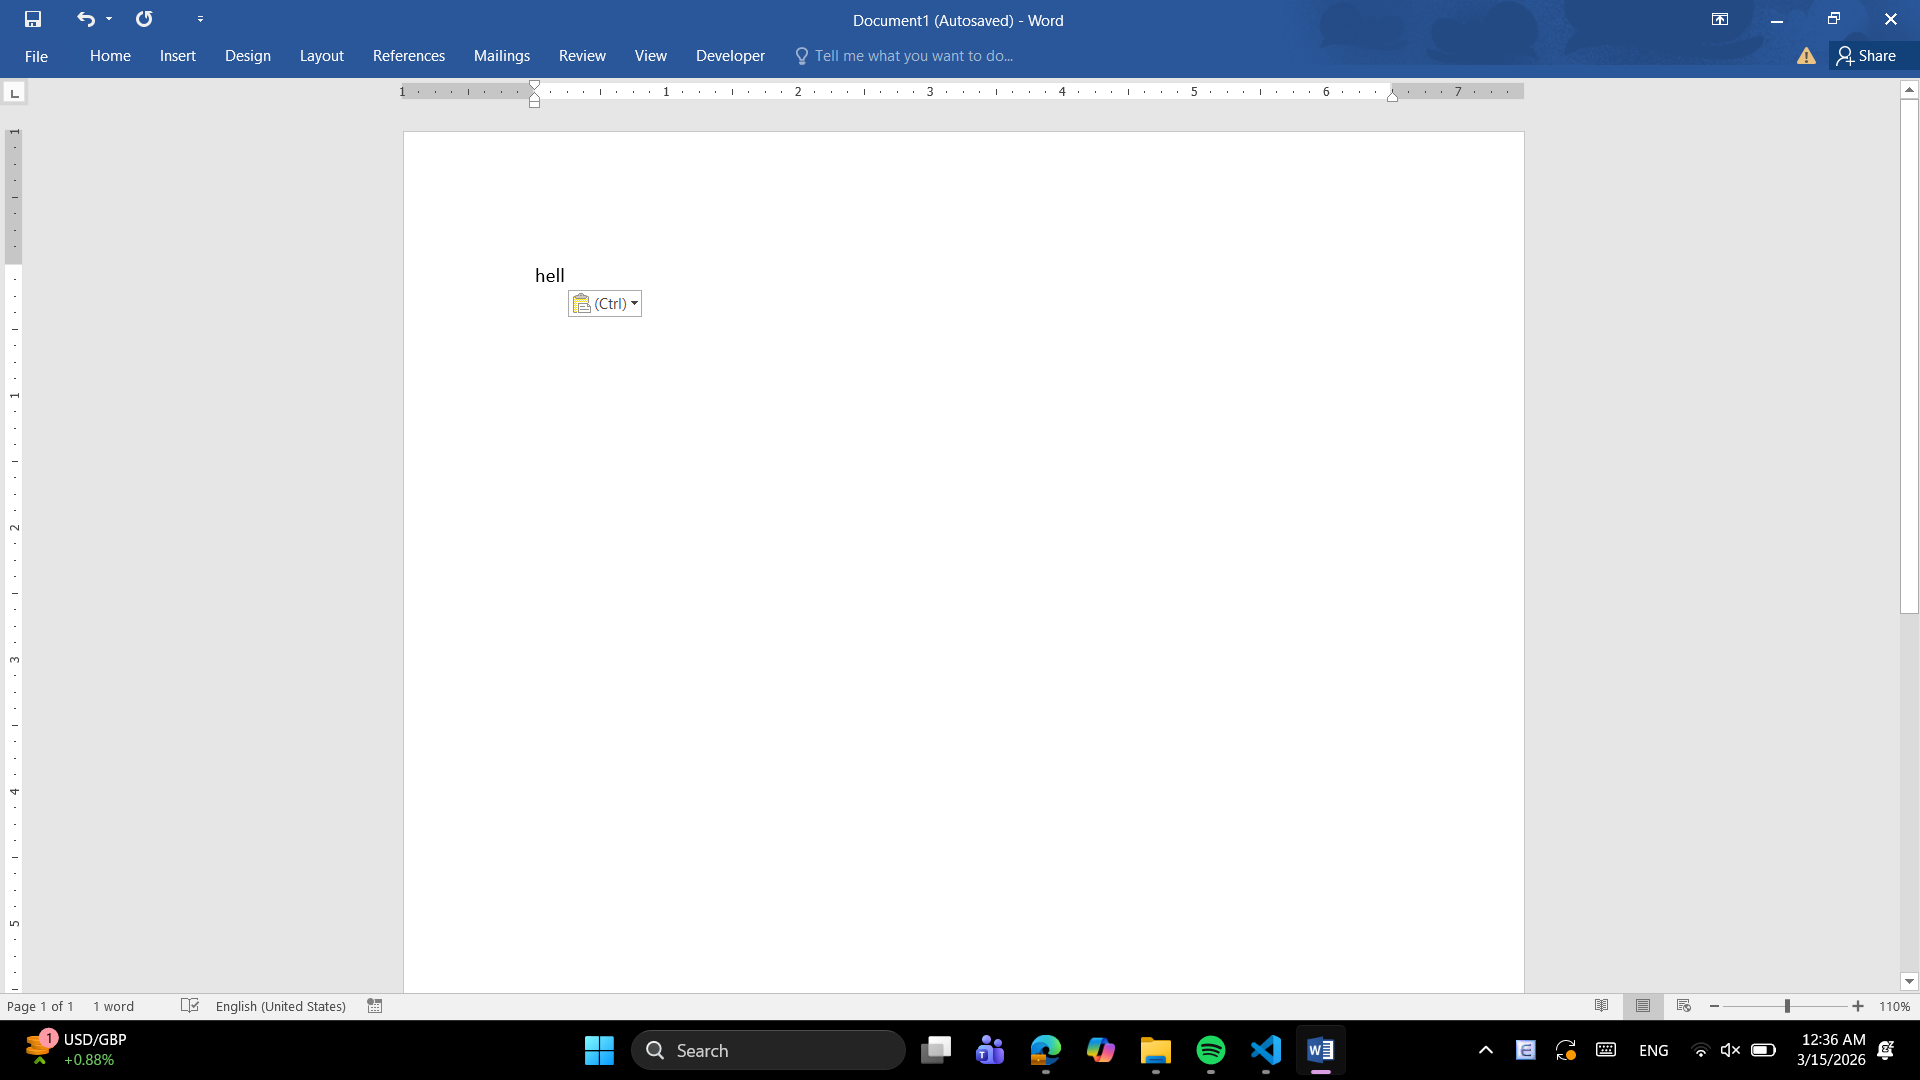

In [2]:
# Cell 9.2: Load image from Google Drive
# Replace the file_id with your own Google Drive shared link ID

from PIL import Image
from IPython.display import display
import requests
from io import BytesIO

# ============ CONFIGURE YOUR GOOGLE DRIVE FILE ID HERE ============
# Get this from your Google Drive sharing link:
# https://drive.google.com/file/d/YOUR_FILE_ID/view?usp=sharing
file_id = "1smpnWckPxedcvYkeItDL7xRy4MQiSMGJ"  # Example - replace with your ID
# ==================================================================

download_url = f"https://drive.google.com/uc?export=download&id={file_id}"
print(f"Downloading image from Google Drive (file_id: {file_id})...")

try:
    # Use a session to handle redirects
    session = requests.Session()
    response = session.get(download_url, timeout=30)
    
    # Check if we got a virus scan warning page (for large files)
    if 'confirm=' in response.text:
        # Extract confirmation token and retry
        import re
        confirm_token = re.search(r'confirm=([0-9A-Za-z_]+)', response.text)
        if confirm_token:
            download_url = f"{download_url}&confirm={confirm_token.group(1)}"
            response = session.get(download_url, timeout=30)
    
    response.raise_for_status()
    user_image = Image.open(BytesIO(response.content)).convert('RGB')
    print(f"✓ Downloaded image from Google Drive")
    print(f"  Size: {user_image.size}")
    display(user_image)
    
except Exception as e:
    print(f"⚠ Error downloading: {e}")
    print("  Trying alternative method with gdown...")
    
    # Fallback: use gdown library
    try:
        import gdown
        
        output_path = '/tmp/downloaded_image.png' if os.name != 'nt' else 'downloaded_image.png'
        gdown.download(id=file_id, output=output_path, quiet=False)
        user_image = Image.open(output_path).convert('RGB')
        print(f"✓ Downloaded image using gdown")
        print(f"  Size: {user_image.size}")
        display(user_image)
    except Exception as e2:
        print(f"⚠ gdown also failed: {e2}")
        print("\n💡 Alternative: Upload image manually and load it:")
        print("   user_image = Image.open('path/to/your/image.png').convert('RGB')")
        raise

✓ SOM utilities loaded from project
✓ Applied in-cell MarkHelper font fix (system DejaVuSans)
Detecting text regions with EasyOCR...
✓ Found 35 text regions

Detected text elements:
  [0] '0' (conf: 0.19)
  [1] '6 '' (conf: 0.51)
  [2] '0' (conf: 0.99)
  [3] 'Document1 (Autosaved)' (conf: 0.82)
  [4] 'Word' (conf: 1.00)
  [5] '6' (conf: 0.54)
  [6] 'X' (conf: 0.77)
  [7] 'File' (conf: 0.60)
  [8] 'Home' (conf: 1.00)
  [9] 'Insert' (conf: 0.77)
  [10] 'Design' (conf: 1.00)
  [11] 'Layout' (conf: 0.96)
  [12] 'References' (conf: 0.98)
  [13] 'Mailings' (conf: 0.90)
  [14] 'Review' (conf: 0.93)
  [15] 'View' (conf: 1.00)
  [16] 'Developer' (conf: 1.00)
  [17] '9 Tell me what you want to do_' (conf: 0.71)
  [18] '9 Share' (conf: 0.59)
  [19] 'hell' (conf: 0.95)
  [20] '(Ctrl)' (conf: 0.71)
  [21] 'Page' (conf: 1.00)
  [22] 'word' (conf: 1.00)
  [23] 'English (United States)' (conf: 0.94)
  [24] '11096' (conf: 0.52)
  [25] 'USD/GBP' (conf: 0.64)
  [26] '12.36 AM' (conf: 0.99)
  [27] '+0.88%

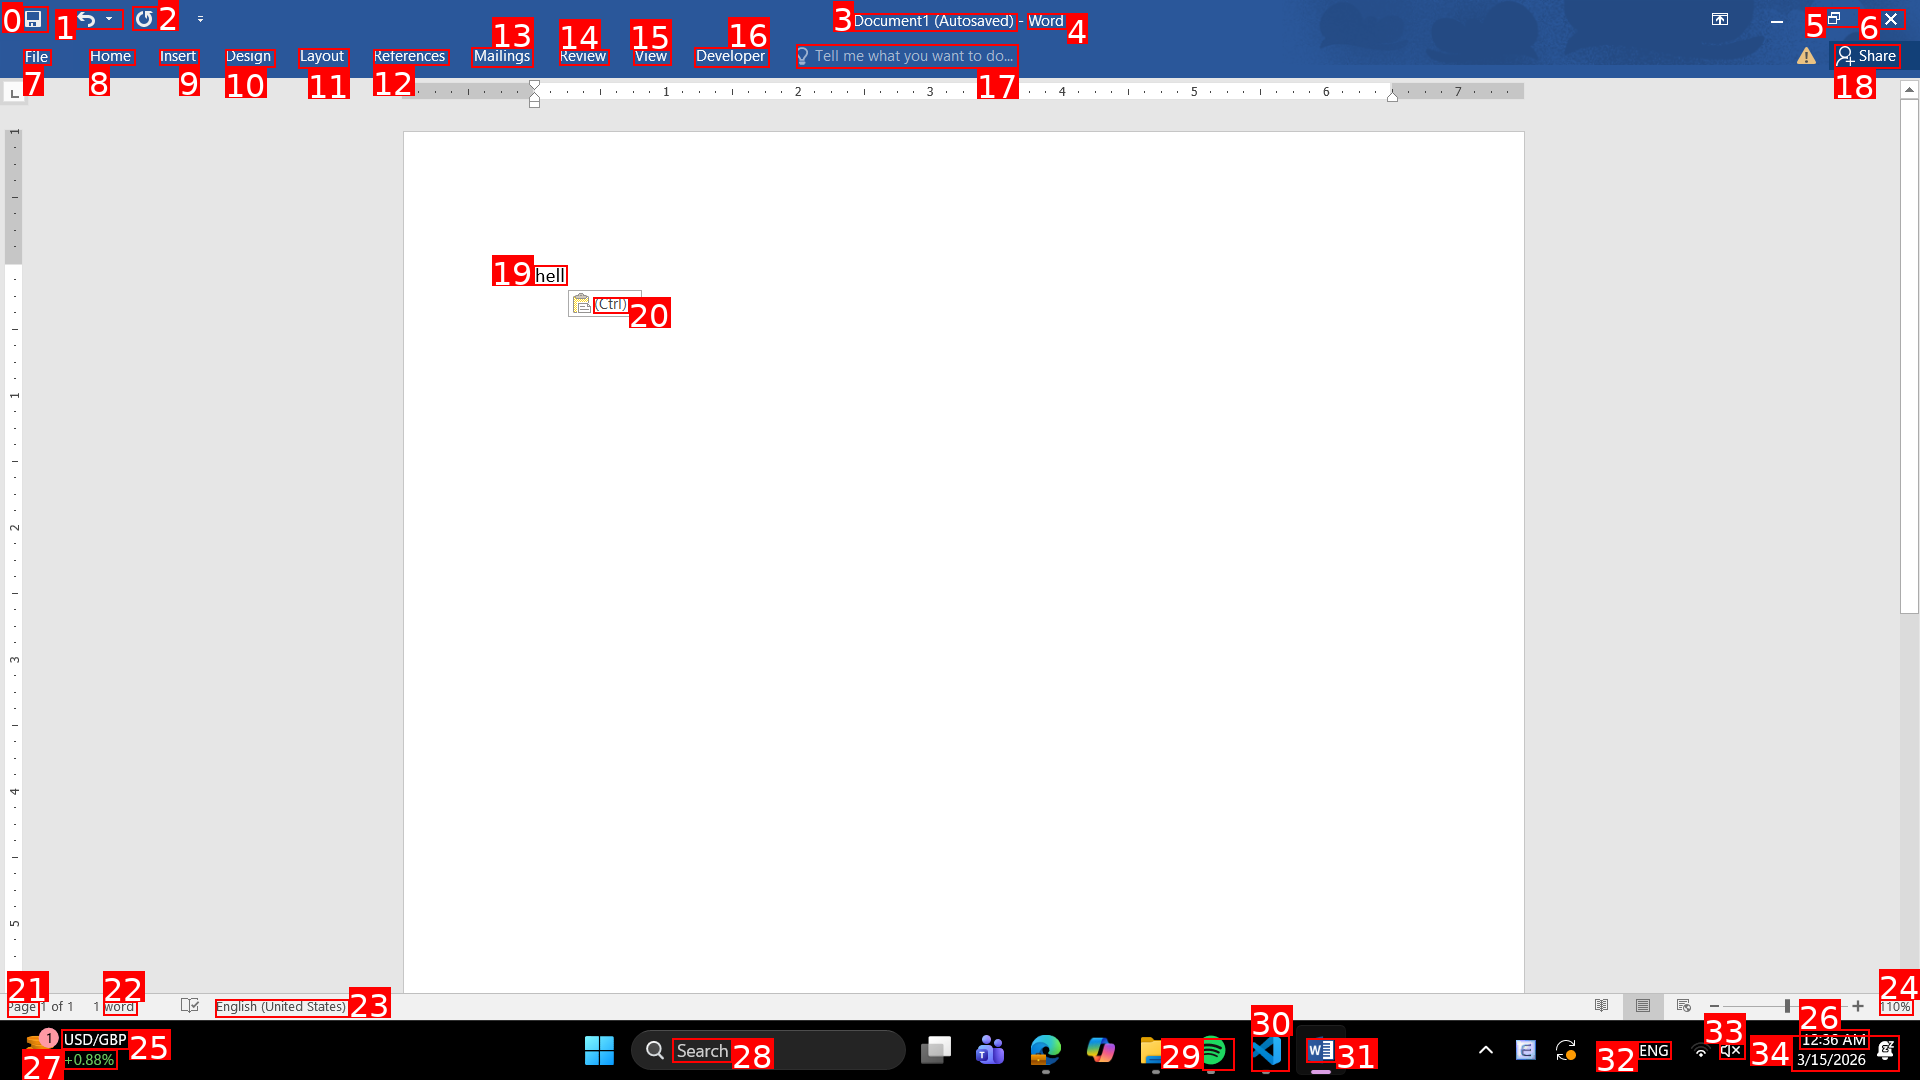

In [5]:
# Cell 9.3b: Simple SOM (OCR only - faster, no YOLO)
import os
import sys
import subprocess
import importlib
from pathlib import Path

import numpy as np
import torch
import easyocr
from PIL import ImageFont
from IPython.display import display

# Define project_root if not already defined
if 'project_root' not in dir():
    cwd = os.getcwd()
    if cwd == '/content':
        project_root = '/content/Magma'
        if not os.path.exists(project_root):
            os.system('git clone https://github.com/microsoft/Magma.git /content/Magma')
    else:
        project_root = cwd
        for _ in range(5):
            if os.path.exists(os.path.join(project_root, 'magma', 'modeling_magma.py')):
                break
            project_root = os.path.dirname(project_root)
    print(f"Project root: {project_root}")

# Add project root to path for SOM utilities
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Optional: pull a PR branch in Colab before importing SOM utilities.
# Example: PR_NUMBER = 123
PR_NUMBER = None

if os.getcwd() == '/content':
    if PR_NUMBER is not None:
        print(f"Fetching PR #{PR_NUMBER} into {project_root}...")
        subprocess.run(["git", "-C", project_root, "fetch", "origin", f"pull/{PR_NUMBER}/head:pr-{PR_NUMBER}"], check=True)
        subprocess.run(["git", "-C", project_root, "checkout", f"pr-{PR_NUMBER}"], check=True)
    else:
        # Keep repo up to date when no PR is specified.
        subprocess.run(["git", "-C", project_root, "pull", "--ff-only"], check=False)

# Force a fresh import from current repo state
import agents.ui_agent.util.som as som_module
som_module = importlib.reload(som_module)
MarkHelper = som_module.MarkHelper
plot_boxes_with_marks = som_module.plot_boxes_with_marks
print("✓ SOM utilities loaded from project")

# In-cell fix: use Colab system DejaVu font (no fallback path).
def _setup_new_font_colab(self, image_height, image_width):
    key = f"{image_height}_{image_width}"
    fontsize = self.min_font_size

    # Colab/Linux system font path
    font_file = Path("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf")
    if not font_file.exists():
        print("Installing system font package: fonts-dejavu-core ...")
        subprocess.run(["apt-get", "update", "-qq"], check=False)
        subprocess.run(["apt-get", "install", "-y", "-qq", "fonts-dejavu-core"], check=True)

    if not font_file.exists():
        raise FileNotFoundError(f"Required system font not found: {font_file}")

    font = ImageFont.truetype(str(font_file), fontsize)
    while min(self._MarkHelper__get_markSize("555", image_height, image_width, font)) < min(
        self.max_font_size, self.max_font_proportion * min(image_height, image_width)
    ):
        fontsize += 1
        font = ImageFont.truetype(str(font_file), fontsize)

    self.font_dict[key] = font
    self.markSize_dict[key] = {
        1: self._MarkHelper__get_markSize('5', image_height, image_width, font),
        2: self._MarkHelper__get_markSize('55', image_height, image_width, font),
        3: self._MarkHelper__get_markSize('555', image_height, image_width, font),
    }

MarkHelper._setup_new_font = _setup_new_font_colab
print("✓ Applied in-cell MarkHelper font fix (system DejaVuSans)")

# Get image dimensions
width, height = user_image.size
image_np = np.array(user_image)

# Collect all bounding boxes (normalized: y, x, h, w)
all_bboxes_normalized = []

# OCR-only detection
print("Detecting text regions with EasyOCR...")
ocr_reader = easyocr.Reader(['en'], gpu=torch.cuda.is_available(), verbose=False)
ocr_results = ocr_reader.readtext(image_np, text_threshold=0.5)
print(f"✓ Found {len(ocr_results)} text regions")

print("\nDetected text elements:")
for i, detection in enumerate(ocr_results):
    coords, text, confidence = detection
    x1, y1 = coords[0]
    x2, y2 = coords[2]
    y_norm = y1 / height
    x_norm = x1 / width
    h_norm = (y2 - y1) / height
    w_norm = (x2 - x1) / width
    all_bboxes_normalized.append((y_norm, x_norm, h_norm, w_norm))
    print(f"  [{i}] '{text}' (conf: {confidence:.2f})")

print(f"\n✓ Total detected regions: {len(all_bboxes_normalized)}")

if len(all_bboxes_normalized) == 0:
    raise RuntimeError("No text regions detected. Cannot render SOM marks.")

# Render SOM marks (no fallback path)
mark_helper = MarkHelper()
som_annotated_image = plot_boxes_with_marks(
    user_image.copy(),
    all_bboxes_normalized,
    mark_helper,
    edgecolor=(255, 0, 0),
    linewidth=2,
    normalized_to_pixel=True,
    add_mark=True
)

print("\n✓ Simple SOM annotation complete!")
display(som_annotated_image)

In [6]:
# Cell 9.4: Load Magma model for custom image evaluation
# Uses the same model loading approach as the main evaluation

# First, ensure ALL required dependencies are installed
import subprocess
import sys

print("Checking/installing Magma model dependencies...")
deps = ["timm", "einops", "einops-exts", "sentencepiece", "open_clip_torch", "peft", "bitsandbytes"]
for dep in deps:
    try:
        __import__(dep.replace("-", "_"))
    except ImportError:
        print(f"  Installing {dep}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", dep])
print("✓ Dependencies ready")

import torch
from transformers import AutoModelForCausalLM, AutoProcessor

# Define globals if not already defined (for standalone execution)
if 'MODEL_DTYPE' not in dir():
    MODEL_DTYPE = torch.bfloat16
if 'DEVICE' not in dir():
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if 'BASE_MODEL' not in dir():
    BASE_MODEL = "microsoft/Magma-8B"

# Check if model is already loaded from earlier evaluation
if 'magma_model' not in dir() or magma_model is None:
    print("Loading Magma model...")
    print(f"Device: {DEVICE}, dtype: {MODEL_DTYPE}")
    
    magma_model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL,
        trust_remote_code=True,
        torch_dtype=MODEL_DTYPE,
        device_map="auto",
        attn_implementation="eager"
    )
    magma_processor = AutoProcessor.from_pretrained(
        BASE_MODEL,
        trust_remote_code=True
    )
    magma_model.eval()
    print("✓ Magma model loaded!")
else:
    print("✓ Using previously loaded Magma model")

Checking/installing Magma model dependencies...
  Installing open_clip_torch...
✓ Dependencies ready
Loading Magma model...
Device: cuda, dtype: torch.bfloat16


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!
A new version of the following files was downloaded from https://huggingface.co/microsoft/Magma-8B:
- image_tower_magma.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Some weights of MagmaForCausalLM were not initialized from the model checkpoint at microsoft/Magma-8B and are newly initialized: ['vision_tower.clip_vision_model.head.proj.weight', 'vision_tower.clip_vision_model.trunk.head.norm.bias', 'vision_tower.clip_vision_model.trunk.head.norm.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/usr/local/lib/python3.12/dist-packages/transformers/models/auto/image_processing_auto.py:647: FutureWarning: The image_processor_class argument is deprecated and will be removed in v4.42. Please use `slow_image_processor_class`, or `fast_image_processor_class` instead
  

✓ Magma model loaded!


Running Magma Inference on SOM-annotated Image

📋 Task: Click the undo button
📜 Previous actions: (None)

🖼️ SOM-annotated image:


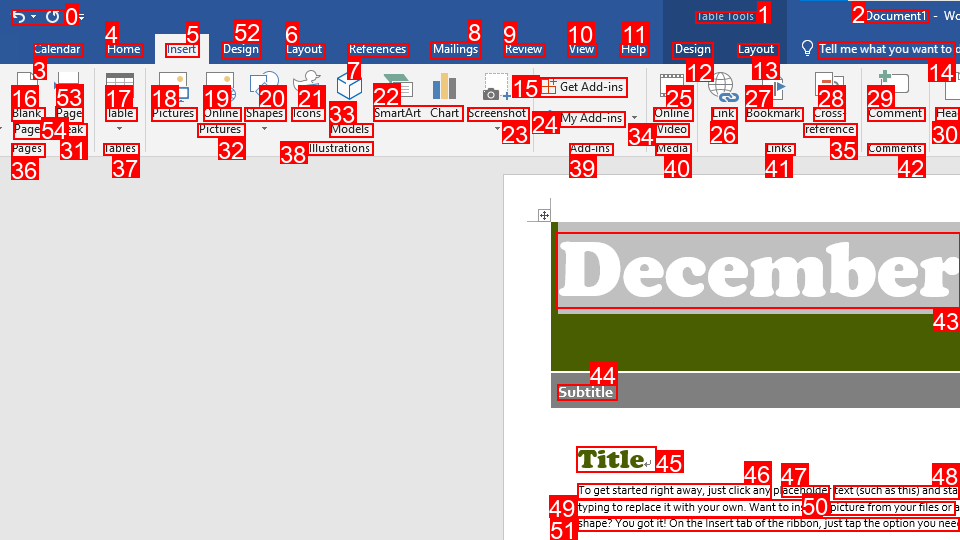


🔄 Running Magma inference...


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)



✅ Raw Response: Coordinate: (0.04, 0.03). Mark: 0

📊 Parsed Action:
   ACTION: None
   MARK:   None
   VALUE:  None


In [7]:
# Cell 9.5: Run Magma inference on SOM-annotated image
# Ask Magma to identify UI elements and navigate

from IPython.display import display
import re

def ask_magma_som(image, task_description, previous_actions=""):
    """
    Query Magma model with a SOM-annotated image for UI navigation.
    
    Args:
        image: PIL Image (SOM-annotated with numbered marks)
        task_description: What task you want to complete
        previous_actions: History of actions taken so far (optional)
    
    Returns:
        Dict with ACTION, MARK, VALUE
    """
    # Build the official Mind2Web prompt format
    prompt = f'''<image>
Imagine that you are imitating humans doing web navigation for a task step by step. At each stage, you can see the webpage like humans by a screenshot and know the previous actions before the current step decided by yourself through recorded history. You need to decide on the following action to take. You can click an element with the mouse, select an option, or type text with the keyboard. The output format should be a dictionary like: 
"{{"ACTION": "CLICK" or "TYPE" or "SELECT", "MARK": a numeric id, e.g., 5, "VALUE": a string value for the action if applicable, otherwise None}}".
You are asked to complete the following task: {task_description}. The previous actions you have taken: 
{previous_actions if previous_actions else "(None)"}
For your convenience, I have labeled the candidates with numeric marks and bounding boxes on the screenshot. What is the next action you would take?
'''
    
    # Handle image token format
    if hasattr(magma_model.config, 'mm_use_image_start_end') and magma_model.config.mm_use_image_start_end:
        prompt = prompt.replace('<image>', '<image_start><image><image_end>')
    
    # Build conversation
    convs = [
        {"role": "system", "content": "You are agent that can see, talk and act."},
        {"role": "user", "content": prompt},
    ]
    
    formatted_prompt = magma_processor.tokenizer.apply_chat_template(
        convs, tokenize=False, add_generation_prompt=True
    )
    
    # Process inputs
    inputs = magma_processor(images=[image], texts=formatted_prompt, return_tensors="pt")
    inputs['pixel_values'] = inputs['pixel_values'].unsqueeze(0)
    inputs['image_sizes'] = inputs['image_sizes'].unsqueeze(0)
    inputs = inputs.to(MODEL_DTYPE).to(DEVICE)
    
    # Generate response
    magma_model.generation_config.pad_token_id = magma_processor.tokenizer.pad_token_id
    
    with torch.inference_mode():
        output_ids = magma_model.generate(
            **inputs,
            temperature=0.0,
            do_sample=False,
            num_beams=1,
            max_new_tokens=256,
            use_cache=False
        )
    
    # Decode response
    prompt_decoded = magma_processor.batch_decode(inputs['input_ids'], skip_special_tokens=True)[0]
    response = magma_processor.batch_decode(output_ids, skip_special_tokens=True)[0]
    response = response.replace(prompt_decoded, '').strip()
    
    return response


def parse_magma_action(response):
    """Parse Magma's action response into structured data."""
    import json
    
    result = {"ACTION": None, "MARK": None, "VALUE": None, "raw": response, "parse_error": False}
    
    # Try to parse as JSON
    try:
        # Find JSON in response
        json_match = re.search(r'\{.*\}', response, re.DOTALL)
        if json_match:
            parsed = json.loads(json_match.group())
            result["ACTION"] = parsed.get("ACTION")
            result["MARK"] = parsed.get("MARK")
            result["VALUE"] = parsed.get("VALUE")
    except json.JSONDecodeError:
        result["parse_error"] = True
    
    return result


# ============ CONFIGURE YOUR TASK HERE ============
task = "Click the undo button"  # Describe your task!
previous_actions = ""  # Optional: list previous actions taken
# ==================================================

print("="*60)
print("Running Magma Inference on SOM-annotated Image")
print("="*60)

print(f"\n📋 Task: {task}")
print(f"📜 Previous actions: {previous_actions if previous_actions else '(None)'}")

# Display the SOM-annotated image
print("\n🖼️ SOM-annotated image:")
display(som_annotated_image)

# Run inference
print("\n🔄 Running Magma inference...")
response = ask_magma_som(som_annotated_image, task, previous_actions)

print(f"\n✅ Raw Response: {response}")

# Parse the response
parsed = parse_magma_action(response)
print(f"\n📊 Parsed Action:")
print(f"   ACTION: {parsed['ACTION']}")
print(f"   MARK:   {parsed['MARK']}")
print(f"   VALUE:  {parsed['VALUE']}")

In [ ]:
# Cell 9.4d: DIAGNOSTIC using Mind2Web dataset sample
# Run this cell to test model with actual Mind2Web data

import torch
import transformers
from transformers import AutoModelForCausalLM, AutoProcessor
from IPython.display import display
import json

print("="*60)
print("DIAGNOSTIC REPORT (Mind2Web Dataset)")
print("="*60)

# 1. Check transformers version
print(f"\n1. Transformers version: {transformers.__version__}")
from packaging import version
tf_ver = version.parse(transformers.__version__)
if tf_ver >= version.parse("5.0.0"):
    print("   ⚠️ CRITICAL: Transformers 5.x detected!")
    print("   FIX: Run: %pip install 'transformers>=4.49.0,<5.0.0' -q")
    TRANSFORMERS_OK = False
elif tf_ver < version.parse("4.49.0"):
    print("   ⚠️ Transformers too old. Magma needs >=4.49.0")
    TRANSFORMERS_OK = False
else:
    print("   ✓ Transformers version OK")
    TRANSFORMERS_OK = True

# 2. Check PyTorch version and CUDA
print(f"\n2. PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# 3. Check if sum patch is applied
print(f"\n3. PyTorch sum() patch: {'✓ Applied' if hasattr(torch, '_original_sum_backup') else '⚠️ NOT applied'}")

# 4. Check if dataset is loaded
if 'dataset' not in dir() or dataset is None:
    print("\n4. ⚠️ Dataset not loaded! Loading Mind2Web from HuggingFace...")
    from datasets import load_dataset
    HF_DATASET_NAME = "MagmaAI/Magma-Mind2Web-SoM"
    HF_DATASET_SPLIT = "train"
    dataset = load_dataset(HF_DATASET_NAME, split=HF_DATASET_SPLIT)
    print(f"   ✓ Dataset loaded: {len(dataset)} samples")
else:
    print(f"\n4. Dataset already loaded: {len(dataset)} samples")

# 5. Get Mind2Web sample
sample = dataset[0]
mind2web_image = sample['image'].convert('RGB')
print(f"\n5. Mind2Web sample info:")
print(f"   Sample ID: {sample.get('id', 'N/A')}")
print(f"   Image size: {mind2web_image.size}")
print(f"   Image mode: {mind2web_image.mode}")

# Get the prompt from conversations
convs = sample.get('conversations', [])
if len(convs) >= 2:
    mind2web_prompt = convs[0].get('value', convs[0].get('content', ''))
    expected_output = convs[1].get('value', convs[1].get('content', ''))
    print(f"   Prompt length: {len(mind2web_prompt)} chars")
    print(f"   Expected output: {expected_output[:100]}...")
else:
    print("   ⚠️ Invalid conversation format")
    raise RuntimeError("Invalid conversation format")

# Display the image
print("\n🖼️ Mind2Web Sample Image:")
display(mind2web_image)

# 6. Test model configurations
print("\n6. Testing model configurations with Mind2Web data...")

if not TRANSFORMERS_OK:
    print("\n   Skipping tests - fix transformers version first!")
else:
    configs_to_try = [
        {"name": "bfloat16 + eager", "dtype": torch.bfloat16, "attn": "eager"},
        {"name": "float16 + eager", "dtype": torch.float16, "attn": "eager"},
    ]

    working_config = None

    for config in configs_to_try:
        print(f"\n   Testing: {config['name']}...")
        
        # Clean up previous model
        if 'test_model' in dir():
            del test_model
        torch.cuda.empty_cache()
        
        try:
            test_model = AutoModelForCausalLM.from_pretrained(
                "microsoft/Magma-8B",
                trust_remote_code=True,
                torch_dtype=config['dtype'],
                device_map="auto",
                attn_implementation=config['attn']
            )
            test_processor = AutoProcessor.from_pretrained(
                "microsoft/Magma-8B",
                trust_remote_code=True
            )
            test_model.eval()
            
            # Use the EXACT prompt from Mind2Web dataset
            test_prompt = mind2web_prompt
            
            # Handle image token format
            if hasattr(test_model.config, 'mm_use_image_start_end') and test_model.config.mm_use_image_start_end:
                test_prompt = test_prompt.replace('<image>', '<image_start><image><image_end>')
            
            # Build conversation
            convs_test = [
                {"role": "system", "content": "You are agent that can see, talk and act."},
                {"role": "user", "content": test_prompt},
            ]
            formatted = test_processor.tokenizer.apply_chat_template(convs_test, tokenize=False, add_generation_prompt=True)
            
            inputs = test_processor(images=[mind2web_image], texts=formatted, return_tensors="pt")
            inputs['pixel_values'] = inputs['pixel_values'].unsqueeze(0)
            inputs['image_sizes'] = inputs['image_sizes'].unsqueeze(0)
            inputs = inputs.to(config['dtype']).to('cuda')
            
            test_model.generation_config.pad_token_id = test_processor.tokenizer.pad_token_id
            
            with torch.inference_mode():
                out = test_model.generate(**inputs, max_new_tokens=256, do_sample=False, use_cache=False)
            
            prompt_dec = test_processor.batch_decode(inputs['input_ids'], skip_special_tokens=True)[0]
            resp = test_processor.batch_decode(out, skip_special_tokens=True)[0].replace(prompt_dec, '').strip()
            
            # Check if garbage
            if '!' * 10 in resp or len(set(resp)) < 5:
                print(f"   ❌ Garbage output: {resp[:50]}...")
            else:
                print(f"   ✓ WORKING!")
                print(f"\n{'='*60}")
                print("MODEL RESPONSE:")
                print('='*60)
                print(resp)
                
                print(f"\n{'='*60}")
                print("EXPECTED OUTPUT:")
                print('='*60)
                try:
                    expected_parsed = json.loads(expected_output) if isinstance(expected_output, str) else expected_output
                    print(json.dumps(expected_parsed, indent=2))
                except json.JSONDecodeError:
                    print(expected_output)
                
                working_config = config
                # Keep this model
                magma_model = test_model
                magma_processor = test_processor
                MODEL_DTYPE = config['dtype']
                break
                
        except Exception as e:
            print(f"   ❌ Error: {str(e)[:80]}...")
            import traceback
            traceback.print_exc()

    # Summary
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)

    if working_config:
        print(f"\n✅ Model working with: {working_config['name']}")
    else:
        print("\n🔴 Model not working with any configuration.")
        print("   Try restarting kernel and running all cells from beginning.")

# Cleanup if needed
if 'test_model' in dir() and 'magma_model' not in dir():
    del test_model
    torch.cuda.empty_cache()

DIAGNOSTIC REPORT (Mind2Web Dataset)

1. Transformers version: 4.57.6
   ✓ Transformers version OK

2. PyTorch: 2.10.0+cu128, CUDA: True
   GPU: NVIDIA A100-SXM4-80GB
   GPU Memory: 85.1 GB

3. PyTorch sum() patch: ⚠️ NOT applied

4. ⚠️ Dataset not loaded! Loading Mind2Web from HuggingFace...


README.md: 0.00B [00:00, ?B/s]

data-00000-of-00012.arrow:   0%|          | 0.00/476M [00:00<?, ?B/s]

data-00001-of-00012.arrow:   0%|          | 0.00/453M [00:00<?, ?B/s]

data-00002-of-00012.arrow:   0%|          | 0.00/465M [00:00<?, ?B/s]

data-00003-of-00012.arrow:   0%|          | 0.00/459M [00:00<?, ?B/s]

data-00004-of-00012.arrow:   0%|          | 0.00/441M [00:00<?, ?B/s]

data-00005-of-00012.arrow:   0%|          | 0.00/445M [00:00<?, ?B/s]

data-00006-of-00012.arrow:   0%|          | 0.00/474M [00:00<?, ?B/s]

In [ ]:
# Cell 9.6: Visualize the predicted action on the image
# Draw a crosshair at the predicted MARK location

from PIL import ImageDraw

if parsed['MARK'] is not None and len(all_bboxes_normalized) > 0:
    mark_idx = int(parsed['MARK'])
    
    if 0 <= mark_idx < len(all_bboxes_normalized):
        # Get the bounding box for this mark
        y_norm, x_norm, h_norm, w_norm = all_bboxes_normalized[mark_idx]
        
        # Calculate center of the bounding box in pixels
        w, h = user_image.size
        center_x = int((x_norm + w_norm/2) * w)
        center_y = int((y_norm + h_norm/2) * h)
        
        # Draw on a copy of the original image
        result_img = user_image.copy()
        draw = ImageDraw.Draw(result_img)
        
        # Draw the bounding box
        x1 = int(x_norm * w)
        y1 = int(y_norm * h)
        x2 = int((x_norm + w_norm) * w)
        y2 = int((y_norm + h_norm) * h)
        draw.rectangle([x1, y1, x2, y2], outline='lime', width=4)
        
        # Draw crosshair at center
        radius = 20
        draw.ellipse([center_x-radius, center_y-radius, center_x+radius, center_y+radius], 
                     outline='red', width=4)
        draw.line([center_x-radius*2, center_y, center_x+radius*2, center_y], fill='red', width=3)
        draw.line([center_x, center_y-radius*2, center_x, center_y+radius*2], fill='red', width=3)
        
        # Add label
        draw.text((x1, y1-25), f"MARK {mark_idx}", fill='lime')
        
        print(f"\n🎯 Predicted click location for MARK {mark_idx}:")
        print(f"   Bounding box: ({x1}, {y1}) to ({x2}, {y2})")
        print(f"   Center point: ({center_x}, {center_y})")
        print(f"\n   Action: {parsed['ACTION']}")
        if parsed['VALUE']:
            print(f"   Value: {parsed['VALUE']}")
        
        display(result_img)
    else:
        print(f"⚠ MARK {mark_idx} is out of range (detected {len(all_bboxes_normalized)} regions)")
else:
    print("⚠ No valid MARK index in the response")

In [ ]:
# Cell 9.7: Interactive query - modify and re-run
# Change the task below and re-run this cell to try different actions

# ============ MODIFY YOUR TASK HERE ============
new_task = "Click the search button"  # Change this!
new_previous_actions = ""  # Optional: add action history
# ===============================================

print(f"🎯 Task: {new_task}")
print("-" * 50)

# Run inference
print("🔄 Running Magma inference...")
new_response = ask_magma_som(som_annotated_image, new_task, new_previous_actions)

print(f"\n✅ Raw Response: {new_response}")

# Parse and visualize
new_parsed = parse_magma_action(new_response)
print(f"\n📊 Parsed Action:")
print(f"   ACTION: {new_parsed['ACTION']}")
print(f"   MARK:   {new_parsed['MARK']}")
print(f"   VALUE:  {new_parsed['VALUE']}")

# Visualize if valid MARK
if new_parsed['MARK'] is not None and len(all_bboxes_normalized) > 0:
    mark_idx = int(new_parsed['MARK'])
    
    if 0 <= mark_idx < len(all_bboxes_normalized):
        y_norm, x_norm, h_norm, w_norm = all_bboxes_normalized[mark_idx]
        w, h = user_image.size
        
        result_img = user_image.copy()
        draw = ImageDraw.Draw(result_img)
        
        x1, y1 = int(x_norm * w), int(y_norm * h)
        x2, y2 = int((x_norm + w_norm) * w), int((y_norm + h_norm) * h)
        center_x, center_y = (x1 + x2) // 2, (y1 + y2) // 2
        
        draw.rectangle([x1, y1, x2, y2], outline='lime', width=4)
        radius = 20
        draw.ellipse([center_x-radius, center_y-radius, center_x+radius, center_y+radius], 
                     outline='red', width=4)
        draw.line([center_x-radius*2, center_y, center_x+radius*2, center_y], fill='red', width=3)
        draw.line([center_x, center_y-radius*2, center_x, center_y+radius*2], fill='red', width=3)
        draw.text((x1, y1-25), f"MARK {mark_idx}", fill='lime')
        
        print(f"\n🎯 Predicted click: MARK {mark_idx} at ({center_x}, {center_y})")
        display(result_img)

## Summary: Custom Image Evaluation Workflow

1. **Cell 9.1**: Install dependencies (ultralytics, easyocr, etc.)
2. **Cell 9.2**: Load your image from Google Drive (update `file_id` with your link)
3. **Cell 9.3**: Run SOM detection (YOLO for icons + EasyOCR for text)
4. **Cell 9.4**: Load the Magma model
5. **Cell 9.5**: Run inference with your task description
6. **Cell 9.6**: Visualize the predicted click location
7. **Cell 9.7**: Interactive mode - change tasks and re-run

### Tips:
- Update the Google Drive `file_id` in Cell 9.2 with your image
- Modify the `task` variable in Cell 9.5 to describe what you want to do
- The MARK index corresponds to the numbered labels in the SOM-annotated image
- For multi-step tasks, add previous actions to the `previous_actions` variable